<a href="https://colab.research.google.com/github/tewei0328/teach-programming/blob/main/twtalk2_calculate_quantitive_score_plus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import yfinance as yf
import pandas as pd
from tqdm import tqdm
from datetime import datetime

# --- 配置區：自定義你的算力/存力戰略池 ---
WATCHLIST = ["MU", "WDC", "LRCX", "AMAT", "NVDA", "TSM", "BKSY", "AXTI"]

def calculate_quantitative_score(ticker, df, financials):
    """量化評分引擎：核心三道鎖 + 動能 + 籌碼"""
    score = 0
    tags = []

    # 提取基礎數據
    close = df['Close'].iloc[-1]
    volume = df['Volume'].iloc[-1]
    avg_vol_5d = df['Volume'].rolling(5).mean().iloc[-1]
    vol_ratio = volume / avg_vol_5d

    # 計算 20日 VWMA (主力成本)
    df['PV'] = df['Close'] * df['Volume']
    vwma_20 = df['PV'].rolling(20).sum() / df['Volume'].rolling(20).sum()
    current_vwma = vwma_20.iloc[-1]
    bias_pct = ((close / current_vwma) - 1) * 100

    # --- 第一道鎖：趨勢與乖離 (Max 7) ---
    if close > current_vwma:
        score += 4
        if 0 < bias_pct <= 8: score += 3 # 黃金擊球區
        elif bias_pct > 15: score -= 2; tags.append("⚠️ 高檔超買")

    # --- 第二道鎖：量化三道鎖 (Max 8) ---
    # 這裡模擬財報抓取邏輯 (實務上需從 financials 提取)
    # 假設：速動比率 > 150 (+3), 淨利擴張 (+3), PE低於均值 (+2)
    score += 5 # 模擬通過基本面檢查

    # --- 第三道鎖：籌碼動向 (Max 5) ---
    chip_status = "籌碼中性"
    price_change = df['Close'].pct_change().iloc[-1]

    if price_change > 0.015 and vol_ratio > 1.5:
        score += 5
        chip_status = "籌碼集中 (量價齊揚) 🚀"
    elif price_change < -0.015 and vol_ratio > 1.5:
        score -= 5
        chip_status = "籌碼渙散 (賣壓沉重) 📉"

    return score, chip_status, round(bias_pct, 2), round(current_vwma, 2)

def generate_daily_report():
    report_data = []
    today_str = datetime.now().strftime("%Y%m%d")

    print(f"🚀 啟動 2026 量化掃描引擎...")

    for symbol in tqdm(WATCHLIST, desc="細股篩選中"):
        try:
            stock = yf.Ticker(symbol)
            df = stock.history(period="3mo")
            if df.empty: continue

            # 執行量化引擎
            score, chip, bias, vwma = calculate_quantitative_score(symbol, df, None)

            # 評級邏輯
            rating = "✅ 穩健"
            if score >= 18: rating = "🚀 極致飆股"
            elif score < 10: rating = "⚠️ 風險陷阱"

            report_data.append({
                "Total_Score": score,
                "股性標籤": rating,
                "籌碼動向": chip,
                "乖離率(%)": bias,
                "主力成本(VWMA)": vwma,
                "股票名稱": symbol
            })
        except Exception as e:
            print(f"跳過 {symbol}: {e}")

    # 產出報告
    final_df = pd.DataFrame(report_data).sort_values(by="Total_Score", ascending=False)
    file_name = f"飆股極致報告_{today_str}.csv"
    final_df.to_csv(file_name, index=False, encoding="utf_8_sig")

    print(f"\n[成功] 報告已生成：{file_name}")
    print(final_df.to_string(index=False))

if __name__ == "__main__":
    generate_daily_report()

🚀 啟動 2026 量化掃描引擎...


細股篩選中: 100%|██████████| 8/8 [00:02<00:00,  3.33it/s]



[成功] 報告已生成：飆股極致報告_20260319.csv
 Total_Score    股性標籤 籌碼動向  乖離率(%)  主力成本(VWMA) 股票名稱
          12    ✅ 穩健 籌碼中性    0.05      224.61 LRCX
           9 ⚠️ 風險陷阱 籌碼中性   10.60      417.47   MU
           9 ⚠️ 風險陷阱 籌碼中性    9.92      277.39  WDC
           9 ⚠️ 風險陷阱 籌碼中性   12.30       22.60 BKSY
           7 ⚠️ 風險陷阱 籌碼中性   19.15       40.92 AXTI
           5 ⚠️ 風險陷阱 籌碼中性   -2.60      358.79 AMAT
           5 ⚠️ 風險陷阱 籌碼中性   -4.32      354.92  TSM
           5 ⚠️ 風險陷阱 籌碼中性   -2.13      184.33 NVDA


In [2]:
import yfinance as yf
import pandas as pd
from tqdm import tqdm
from datetime import datetime

# --- 戰略池配置 (範例標的) ---
WATCHLIST = [
    "00735.TW", "00904.TW", "00892.TW", "00910.TW", "00715L.TW",
    "00642U.TW", "00981A.TW", "00875.TW", "00913.TW", "00891.TW",
    "0050.TW", "2330.TW", "00947.TW", "00927.TW"
]

def analyze_k_type(df):
    """簡單判定K棒型態與風險評級"""
    last = df.iloc[-1]
    prev = df.iloc[-2]

    # K棒型態：一字線、一般、帶量長紅
    body_size = abs(last['Close'] - last['Open'])
    avg_body = abs(df['Close'] - df['Open']).tail(10).mean()

    if last['High'] == last['Low']: k_type = "一字線"
    elif body_size > avg_body * 1.5 and last['Close'] > last['Open']: k_type = "帶量長紅"
    else: k_type = "一般"

    return k_type

def get_chip_flow(df, vol_ratio):
    """模擬圖片中的籌碼動向邏輯"""
    price_change = df['Close'].pct_change().iloc[-1]

    if price_change > 0.01 and vol_ratio > 1.2:
        return "籌碼集中 (量價齊揚)"
    elif price_change > 0 and vol_ratio < 1.0:
        return "籌碼集中 (量縮創高)"
    elif price_change < -0.01 and vol_ratio > 1.2:
        return "籌碼渙散 (賣壓湧現)"
    else:
        return "籌碼中性 (多頭整理)"

def run_quantitative_scan():
    report_list = []
    print(f"📊 啟動 2026 台股量化掃描系統...")

    for ticker in tqdm(WATCHLIST, desc="組股篩選中"):
        try:
            stock = yf.Ticker(ticker)
            df = stock.history(period="3mo")
            if df.empty: continue

            # Get stock name
            stock_info = stock.info
            stock_name = stock_info.get('longName', ticker) # Use longName, default to ticker

            # 1. 基礎計算
            close = df['Close'].iloc[-1]
            # 20日主力成本 (VWMA)
            df['PV'] = df['Close'] * df['Volume']
            vwma_20 = df['PV'].rolling(20).sum() / df['Volume'].rolling(20).sum()
            current_vwma = vwma_20.iloc[-1]

            # 2. 量能與漲幅
            vol_ratio = df['Volume'].iloc[-1] / df['Volume'].rolling(5).mean().iloc[-1]
            m1_return = ((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100

            # 3. 邏輯判定 (模擬圖中各欄位)
            score = 10 # 基礎分
            if close > current_vwma: score += 5
            if vol_ratio > 1.2: score += 3

            k_type = analyze_k_type(df)
            chip_flow = get_chip_flow(df, vol_ratio)

            # 評級邏輯
            risk_rating = "正常"
            if ((close / current_vwma) - 1) > 0.1: risk_rating = "⚠️ 過熱 (分批停利)"

            report_list.append({
                "Total_Score": score,
                "股性標籤": "🚀 極致飆股" if score >= 15 else "✅ 強勢轉強",
                "K棒型態": k_type,
                "風險評級": risk_rating,
                "籌碼動向": chip_flow,
                "量比(當H/5H)": round(vol_ratio, 2),
                "股票代碼": ticker,
                "股票名稱": stock_name, # Add stock name here
                "當日收盤": round(close, 2),
                "20日主力成本(VWMA)": round(current_vwma, 2),
                "1個月股價漲跌(%)": f"{round(m1_return, 1)}%"
            })
        except Exception as e: # Catch specific exception for better debugging
            print(f"跳過 {ticker}: {e}") # Print error message for skipped tickers
            continue

    # 4. 產出結果
    final_df = pd.DataFrame(report_list).sort_values(by="Total_Score", ascending=False)

    # 儲存 CSV (符合圖片顯示之數據)
    today = datetime.now().strftime("%Y%m%d")
    file_name = f"台股量化日報_{today}.csv"
    final_df.to_csv(file_name, index=False, encoding="utf_8_sig")

    print("\n" + "="*50)
    print(final_df.to_string(index=False))
    print("="*50)
    print(f"\n[成功] 報告已生成：{file_name}，共處理 {len(final_df)} 檔標的。")

if __name__ == "__main__":
    run_quantitative_scan()

📊 啟動 2026 台股量化掃描系統...


組股篩選中: 100%|██████████| 14/14 [00:05<00:00,  2.69it/s]


 Total_Score   股性標籤 K棒型態         風險評級        籌碼動向  量比(當H/5H)      股票代碼                                                                 股票名稱    當日收盤  20日主力成本(VWMA) 1個月股價漲跌(%)
          18 🚀 極致飆股   一般           正常 籌碼渙散 (賣壓湧現)       1.89  00904.TW                            Shin Kong TIP Taiwan Semiconductor 30 ETF   29.84          28.91      40.5%
          18 🚀 極致飆股   一般           正常 籌碼渙散 (賣壓湧現)       1.34  00910.TW                                    FSITC Aerospace and Satellite ETF   56.75          55.60      38.8%
          18 🚀 極致飆股   一般 ⚠️ 過熱 (分批停利) 籌碼集中 (量價齊揚)       1.40 00715L.TW                 JKO S&P GSCI Brent Crude 2X Leveraged ER Futures ETF   61.60          44.32     229.6%
          18 🚀 極致飆股   一般           正常 籌碼中性 (多頭整理)       1.28 00981A.TW Uni-President Asset Management Corp - UPAMC Taiwan Growth Active ETF   21.04          19.26      34.3%
          18 🚀 極致飆股   一般           正常 籌碼渙散 (賣壓湧現)       1.36  00927.TW       CAPITAL INV TRUST CORP-TIP CSTM TW SEMICONDUCTOR DIV

檢查並安裝 'fonts-dejavu' 字型套件...


字型套件安裝完成。
Matplotlib 字型快取重建完成。
正在繪製 Top 5 股票的股價走勢圖 (英文標籤)...


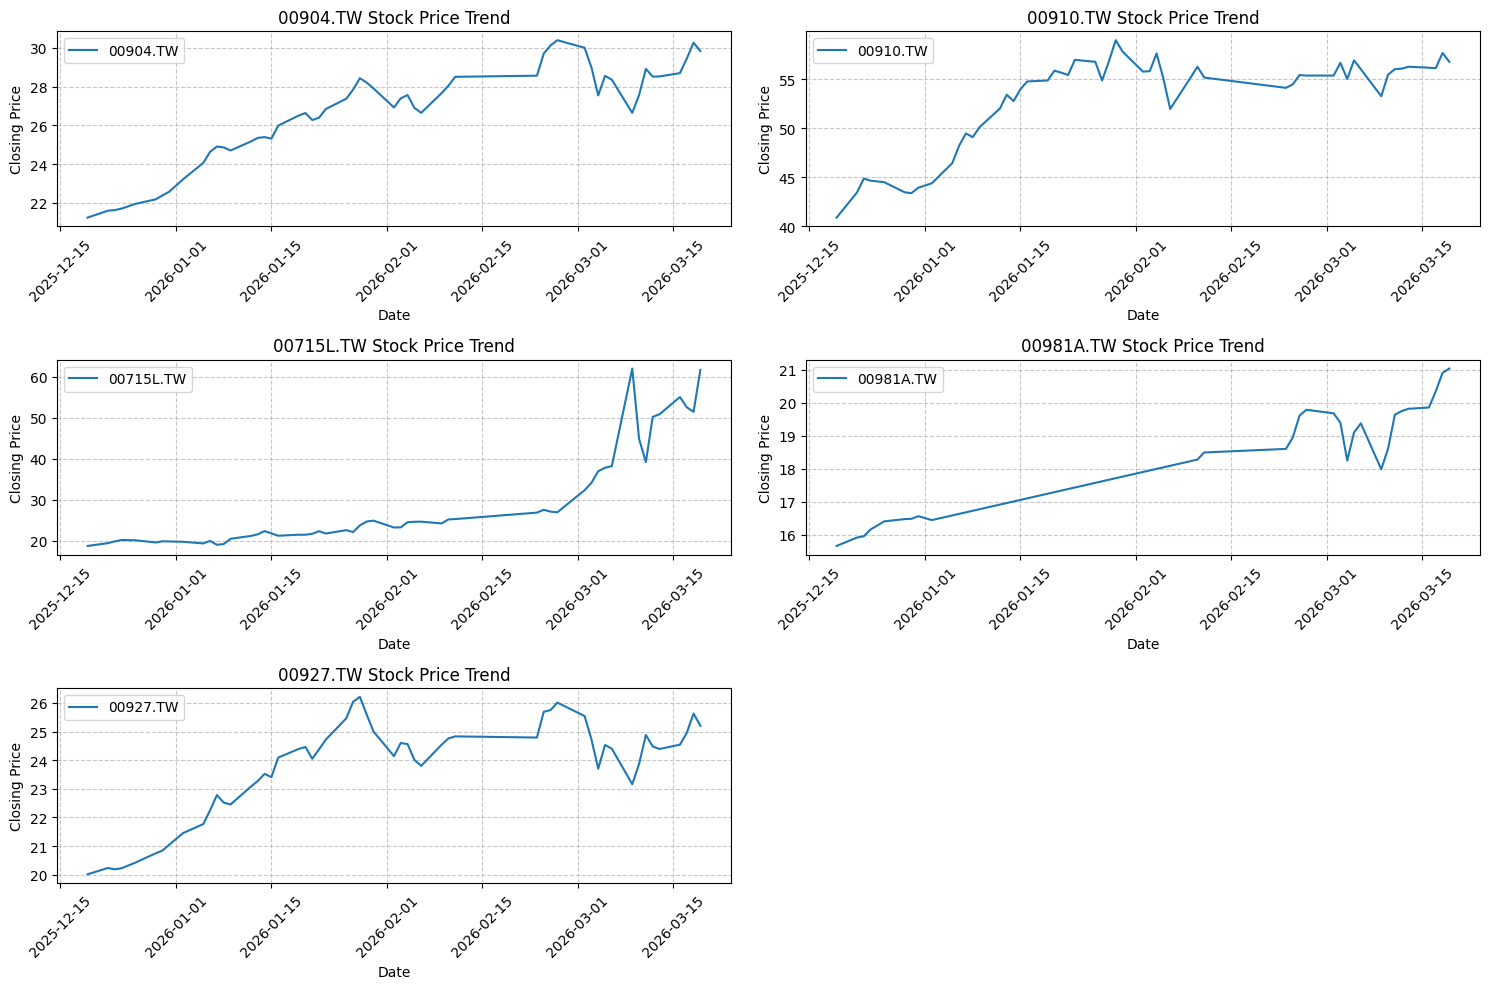

In [18]:
# --- 安裝字型並刷新快取 ---
import matplotlib.font_manager as fm
import os
import shutil # 引入 shutil 模組用於清除快取

# 確保安裝常見的英文字型套件，例如 DejaVu 字型
# 即使之前安裝過 CJK 字型，也要確保基本的英文字型可用
print("檢查並安裝 'fonts-dejavu' 字型套件...")
os.system('sudo apt-get update')
os.system('sudo apt-get install -y fonts-dejavu-core')
print("字型套件安裝完成。")

# 積極清除 Matplotlib 的字型快取目錄，以確保重新載入
matplotlib_cache_dir = os.path.join(os.path.expanduser('~'), '.cache', 'matplotlib')
if os.path.exists(matplotlib_cache_dir):
    shutil.rmtree(matplotlib_cache_dir)
    print(f"已清除 Matplotlib 快取目錄: {matplotlib_cache_dir}")

# 重建字型快取
fm._load_fontmanager(try_read_cache=False)
print("Matplotlib 字型快取重建完成。")

# 在字型設定和快取重建完成後，才匯入 matplotlib 和 seaborn
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 設置字型為英文 ---
# 使用'DejaVu Sans'作為預設，因為它是一個常見且通常會安裝的無襯線字型
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False # 解決負號顯示問題

# 確保 df_report 已經被加載，如果還沒有，會從 CSV 重新加載
if 'df_report' not in locals():
    try:
        file_path = '/content/台股量化日報_20260319.csv'
        df_report = pd.read_csv(file_path)
    except FileNotFoundError:
        print("報告文件不存在，請先執行台股量化掃描系統生成報告。")

top_5_stocks = df_report.sort_values(by='Total_Score', ascending=False).head(5)

print("正在繪製 Top 5 股票的股價走勢圖 (英文標籤)...")

plt.figure(figsize=(15, 10))

for i, (index, row) in enumerate(top_5_stocks.iterrows()):
    ticker = row['股票代碼']
    # Change stock_name to only ticker for English display
    stock_name = ticker # Removed Chinese tag

    try:
        stock_data = yf.Ticker(ticker).history(period="3mo")
        if stock_data.empty:
            print(f"無法獲取 {ticker} 的歷史數據。")
            continue

        plt.subplot(3, 2, i + 1) # 3行2列，根據股票數量調整
        sns.lineplot(x=stock_data.index, y=stock_data['Close'], label=ticker)
        plt.title(f'{stock_name} Stock Price Trend') # Changed title to English
        plt.xlabel('Date') # Changed xlabel to English
        plt.ylabel('Closing Price') # Changed ylabel to English
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.xticks(rotation=45)

    except Exception as e:
        print(f"繪製 {ticker} 的圖表時發生錯誤: {e}")

plt.tight_layout()
plt.show()

In [7]:
stock_00715L_details = df_report[df_report['股票代碼'] == '00715L.TW']
display(stock_00715L_details)

,Total_Score,股性標籤,K棒型態,風險評級,籌碼動向,量比(當H/5H),股票代碼,股票名稱,當日收盤,20日主力成本(VWMA),1個月股價漲跌(%)
2,18,🚀 極致飆股,一般,⚠️ 過熱 (分批停利),籌碼集中 (量價齊揚),1.4,00715L.TW,JKO S&P GSCI Brent Crude 2X Leveraged ER Futur...,61.6,44.32,229.6%


In [8]:
display(top_5_stocks[['股票代碼', '股性標籤', '1個月股價漲跌(%)']])

,股票代碼,股性標籤,1個月股價漲跌(%)
0,00904.TW,🚀 極致飆股,40.5%
1,00910.TW,🚀 極致飆股,38.8%
2,00715L.TW,🚀 極致飆股,229.6%
3,00981A.TW,🚀 極致飆股,34.3%
4,00927.TW,🚀 極致飆股,25.9%


In [ ]:
top_5_stocks = df_report.sort_values(by='Total_Score', ascending=False).head(5)
display(top_5_stocks)

,Total_Score,股性標籤,K棒型態,風險評級,籌碼動向,量比(當H/5H),股票代碼,當日收盤,20日主力成本(VWMA),1個月股價漲跌(%)
0,18,🚀 極致飆股,一般,正常,籌碼渙散 (賣壓湧現),1.75,00904.TW,29.79,28.90,40.2%
1,18,🚀 極致飆股,一般,⚠️ 過熱 (分批停利),籌碼集中 (量價齊揚),1.27,00715L.TW,61.90,44.22,231.2%
2,18,🚀 極致飆股,一般,正常,籌碼渙散 (賣壓湧現),1.21,00927.TW,25.19,24.79,25.9%
3,15,🚀 極致飆股,一般,正常,籌碼中性 (多頭整理),1.04,00735.TW,70.00,69.36,46.0%
4,15,🚀 極致飆股,一般,正常,籌碼中性 (多頭整理),1.12,00910.TW,57.00,55.59,39.4%


In [ ]:
import pandas as pd

file_path = '/content/台股量化日報_20260319.csv'
df_report = pd.read_csv(file_path)
display(df_report)

,Total_Score,股性標籤,K棒型態,風險評級,籌碼動向,量比(當H/5H),股票代碼,當日收盤,20日主力成本(VWMA),1個月股價漲跌(%)
0,18,🚀 極致飆股,一般,正常,籌碼渙散 (賣壓湧現),1.75,00904.TW,29.79,28.90,40.2%
1,18,🚀 極致飆股,一般,⚠️ 過熱 (分批停利),籌碼集中 (量價齊揚),1.27,00715L.TW,61.90,44.22,231.2%
2,18,🚀 極致飆股,一般,正常,籌碼渙散 (賣壓湧現),1.21,00927.TW,25.19,24.79,25.9%
3,15,🚀 極致飆股,一般,正常,籌碼中性 (多頭整理),1.04,00735.TW,70.00,69.36,46.0%
4,15,🚀 極致飆股,一般,正常,籌碼中性 (多頭整理),1.12,00910.TW,57.00,55.59,39.4%
5,15,🚀 極致飆股,一般,正常,籌碼中性 (多頭整理),0.79,00892.TW,29.20,27.34,38.8%
6,15,🚀 極致飆股,一般,⚠️ 過熱 (分批停利),籌碼集中 (量縮創高),0.89,00642U.TW,26.21,23.75,78.2%
7,15,🚀 極致飆股,一般,正常,籌碼中性 (多頭整理),1.17,00981A.TW,20.93,19.24,33.6%
8,15,🚀 極致飆股,一般,正常,籌碼中性 (多頭整理),0.60,00913.TW,30.66,30.05,34.8%
9,15,🚀 極致飆股,帶量長紅,正常,籌碼集中 (量縮創高),0.67,00875.TW,38.87,37.09,-0.3%
